# Logistic regression

## Imports

After the baseline, I decided to try two simple models: logistic regression and decision tree. I want to compare these two approaches and then, if necessary, move on to a more complex models.

In [1]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from heart_failure.dataset import split_data
from heart_failure.features import get_fe_pipeline
from heart_failure.modeling.models import build_lr_pipeline
from heart_failure.modeling.train import optuna_search, lr_space
from heart_failure.config.modeling import CV_SPLITS, OPTUNA_N_TRIALS, LR_SCORING, F_BETA_THRESHOLD
from heart_failure.config.config import INTERIM_DATA_DIR, HEART_DISEASE, SEX, PROCESSED_DATA_DIR
from heart_failure.config.features import TEST_SIZE, RANDOM_STATE, VAL_SIZE
from heart_failure.reports import print_best_params
from heart_failure.modeling.evaluate import (
    get_metrics, log_metrics, optuna_cv_results_to_df, find_best_threshold, find_max_recall_by_pr
)
from heart_failure.modeling.predict import predict_by_threshold
from heart_failure.plots import plot_pr_curve

2026-06-19 11:42:27.000 | INFO     | heart_failure.config.config:<module>:11 - PROJ_ROOT path is: D:\heart_failure


In [2]:
MODEL_NAME = "logistic_regression"
mlflow.set_experiment(f"heart_failure")

<Experiment: artifact_location='file:D:/heart_failure/notebooks/mlruns/1', creation_time=1781534399229, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781534399229, lifecycle_stage='active', name='heart_failure', tags={}, trace_location=None, workspace='default'>

In [2]:
df = pd.read_csv(INTERIM_DATA_DIR / "heart.csv")
rem_columns = pd.read_csv(PROCESSED_DATA_DIR / "remaining_cols.csv")
rem_columns = rem_columns.squeeze().to_list()

y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

X_train, y_train, X_val, y_val, X_test, y_test = split_data(
    X, y, stratify_func=lambda X, y: pd.concat([X[[SEX]], y], axis=1)
)

## Training

In [ ]:
fe_pipeline = get_fe_pipeline()
study, model = optuna_search(
    X_train,
    y_train,
    model_builder=build_lr_pipeline,
    param_space=lr_space,
    n_trials=OPTUNA_N_TRIALS,
    n_splits=CV_SPLITS,
    scoring=LR_SCORING,
    random_state=RANDOM_STATE,
    fe_pipeline=fe_pipeline,
    rem_columns=rem_columns,
)

In [5]:
print_best_params(study)

Best parameters: {'model__solver': 'liblinear', 'model__C': 0.004911959763722533, 'model__max_iter': 426, 'model__tol': 3.7415335532873465e-05, 'model__l1_ratio': 0}
Best score: 0.93104


In [6]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
24,"{'model__solver': 'liblinear', 'model__C': 0.0...",0.026633,0.931041,0.921116,0.886888,0.942092,0.967566,0.937543,1
36,"{'model__solver': 'liblinear', 'model__C': 0.0...",0.026296,0.931022,0.921313,0.887275,0.942455,0.966795,0.937272,2
42,"{'model__solver': 'liblinear', 'model__C': 0.0...",0.026587,0.931008,0.921116,0.886888,0.942092,0.967399,0.937543,3
39,"{'model__solver': 'liblinear', 'model__C': 0.0...",0.026387,0.930913,0.921027,0.887167,0.942058,0.967041,0.937272,4
34,"{'model__solver': 'liblinear', 'model__C': 0.0...",0.026376,0.930801,0.921027,0.887081,0.941582,0.967041,0.937272,5


The scores for different trials are very similar. Hyperparameters don't have that much of an impact on the results in this case. So, we're limited by the informativeness of the features.

In [7]:
lr = model.named_steps["model"]
weights = pd.Series(lr.coef_.ravel(), index=rem_columns)
weights.sort_values(key=abs, ascending=False)

target_encoder__ST_Slope          0.338021
remainder__conjunctive_rules      0.328287
target_encoder__ChestPainType     0.266370
binary_encoder__ExerciseAngina    0.205339
binary_encoder__Sex               0.186311
remainder__Oldpeak                0.168079
binary_encoder__FastingBS         0.152869
binarizer__MaxHR                 -0.131211
binarizer__Cholesterol            0.085930
remainder__MaxHR_z               -0.081998
binarizer__Age                    0.081334
dtype: float64

The model barely considers MaxHR. ST_Slope is perceived as the best feature, followed by conjunctive_rules. These two features are quite correlated (~0.75). What happens if we remove one of these features entirely?

### Threshold searching

In [4]:
y_train_proba = model.predict_proba(X_train)[:, 1]
best_threshold = find_best_threshold(y_train, y_train_proba, F_BETA_THRESHOLD)
best_threshold

np.float64(0.385)

The value 1.5 was chosen as beta, since at higher values the threshold drops too low, and class 0 is not predicted at all.

## Metrics

In [5]:
print("Train metrics")
y_train_pred = predict_by_threshold(model, X_train, best_threshold)
train_metrics = get_metrics(y_train, y_train_pred, y_train_proba)
train_metrics

Train metrics


precision    0.817961
recall       0.946629
f2_score     0.917756
pr_auc       0.933610
dtype: float64

In [9]:
print("Validate metrics")
y_val_pred = predict_by_threshold(model, X_val, best_threshold)
y_val_proba = model.predict_proba(X_val)[:, 1]
val_metrics = get_metrics(y_val, y_val_pred, y_val_proba)
val_metrics

Validate metrics


precision    0.771930
recall       0.897959
f2_score     0.869565
pr_auc       0.916970
dtype: float64

Recall is slightly worse than baseline (FN is 1 more). Although precision is better, this result is unsatisfactory. The validate result is worse than the train result (as is the case for the baseline). The heuristic values in the rules were overfitted. Perhaps the threshold for retaining a rule is too low. The problem is that these rules were initially applied to the entire train, so it's impossible to select a threshold in optuna, as there's a leak. In that case, I can try building trees using only the initial tansformed features.

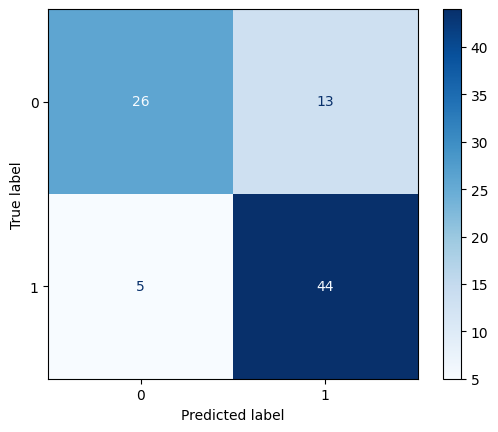

In [10]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, cmap="Blues")
plt.show()

In this case, FP, FN practically the same as for the baseline.

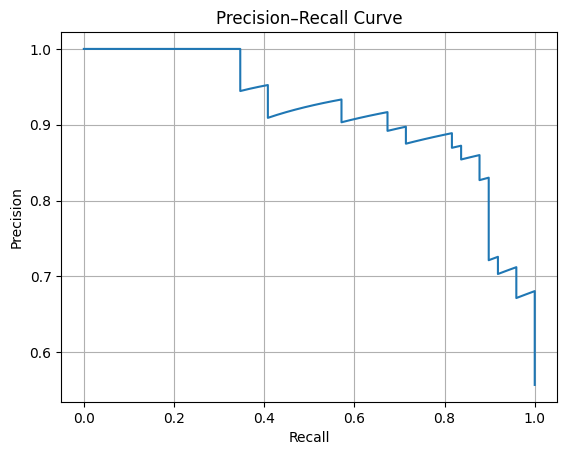

In [11]:
plot_pr_curve(y_val, y_val_proba)

In [12]:
best_threshold = find_max_recall_by_pr(y_val, y_val_proba)
round(best_threshold, 3)

np.float64(0.205)

In [13]:
print("Test metrics")
y_test_pred = predict_by_threshold(model, X_test, best_threshold)
y_test_proba = model.predict_proba(X_test)[:, 1]
test_metrics = get_metrics(y_test, y_test_pred, y_test_proba)
test_metrics

Test metrics


precision    0.677852
recall       0.990196
f2_score     0.906643
pr_auc       0.914551
dtype: float64

I focus primarily on validate to avoid leaks. The model showed worse results than the baseline. I don't think logistic regression is appropriate in this case, so I want to try a decision tree.

In [ ]:
with mlflow.start_run(run_name=MODEL_NAME) as run:
    mlflow.log_param("model", MODEL_NAME)
    mlflow.log_param("test_size", TEST_SIZE)
    mlflow.log_param("val_size", VAL_SIZE)
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("cv_splits", CV_SPLITS)
    mlflow.log_param("optuna_n_trials", OPTUNA_N_TRIALS)
    mlflow.log_param("remaining_columns", rem_columns)
    mlflow.log_param("f_beta_threshold", F_BETA_THRESHOLD)
    mlflow.log_param("proba_threshold", best_threshold)

    mlflow.sklearn.log_model(sk_model=model, name=MODEL_NAME)

    log_metrics(train_metrics, "train_")
    log_metrics(val_metrics, "val_")
    log_metrics(test_metrics, "test_")